## 訓練 ViT

### 初始化

In [1]:
import os
import math
import timm
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score, roc_curve, auc

# 樣本等級
SAMPLE_SIZE = 10000# 1000, 2000, 5000 或 10000

# 模型名稱與路徑
MODEL_NAME = f'model_{SAMPLE_SIZE}'
output_dir = f'{MODEL_NAME}'  
CKPT_PATH = f'{MODEL_NAME}.pth.tar'  
os.makedirs(output_dir, exist_ok=True)

# 模型類別
N_CLASSES = 15
CLASS_NAMES = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion'
               , 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding'
               , 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

# 資料路徑
DATA_DIR = '/kaggle/input/datasets/davidkuo3/nih-chestx-ray14-10000/images'
CSV_PATH = '/kaggle/input/datasets/davidkuo3/nih-label/label.csv'

# 顧名思義
EPOCHS = 20
BATCH_SIZE = 32
LR = 1e-5 # 學習率

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"=> 目前裝置: {device}")

=> 目前裝置: cuda


In [2]:
class CustomChestXrayDataSet(Dataset):
    def __init__(self, csv_path, data_dir, split, transform=None, sample_level=10000):
        """
        Args:
            csv_path: 完整 CSV 的路徑
            data_dir: 圖片資料夾路徑
            split: 'train', 'val', 或 'test'
            transform: 影像前處理轉換
            sample_level: 樣本大小等級，可填 1000, 2000, 5000 或 10000
        """
        df_all = pd.read_csv(csv_path)
        df_split = df_all[df_all['Split'] == split].reset_index(drop=True)
        
        if int(sample_level) < len(df_split):
            target_size = int(sample_level)
            self.df = df_split.sample(n=target_size, random_state=42).reset_index(drop=True)
        else:
            self.df = df_split
            
        self.data_dir = data_dir
        self.transform = transform

    def __getitem__(self, index):
        row = self.df.iloc[index]
        img_name = row['Image Index']
        img_path = os.path.join(self.data_dir, img_name)
        
        image = Image.open(img_path).convert('RGB')
        label = np.array(row[CLASS_NAMES].values, dtype=np.float32)
        
        if self.transform is not None:
            image = self.transform(image)
            
        return image, torch.FloatTensor(label)

    def __len__(self):
        return len(self.df)

# 定義模型
def ViT(num_classes, pretrained=True):
    model = timm.create_model('vit_base_patch16_224', pretrained=pretrained)
    
    num_ftrs = model.head.in_features
    model.head = nn.Linear(num_ftrs, num_classes)
    
    return model


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        alpha: 類別權重，可以是 list 或 tensor，長度需與類別數相同。
               例如你原本的 [5.0, 2.0, 1.0]
        gamma: 聚焦參數，預設 2.0。值越大，模型越專注於難分類的樣本。
        """
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        if alpha is not None:
            if not isinstance(alpha, torch.Tensor):
                alpha = torch.tensor(alpha, dtype=torch.float32)
            self.register_buffer('alpha', alpha)
        else:
            self.alpha = None

    def forward(self, inputs, targets):
        probs = torch.sigmoid(inputs)
        
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        
        pt = targets * probs + (1 - targets) * (1 - probs)
        
        focal_weight = (1 - pt) ** self.gamma
        loss = focal_weight * bce_loss

        if self.alpha is not None:
            alpha_weight = targets * self.alpha + (1 - targets) * 1.0
            loss = alpha_weight * loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

### 讀取資料

#### 訓練集

In [3]:
# 測試集資料增強
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomAffine(
        degrees=5,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02)
    ),
    transforms.ColorJitter(
        brightness=0.08,
        contrast=0.08
    ),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.1, scale=(0.01, 0.02)), 
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# 驗證集
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

class ManagedTransformDataset(CustomChestXrayDataSet):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        if not hasattr(self, 'split'):
            if hasattr(self, 'mode'):
                self.split = self.mode
            else:
                self.split = kwargs.get('split', 'train')

    def __getitem__(self, index):
        row = self.df.iloc[index]

        img_path = os.path.join(self.data_dir, row["Image Index"])
        image = Image.open(img_path).convert("RGB")

        labels = row[CLASS_NAMES].values.astype(np.float32)
        labels = torch.tensor(labels)

        if 'train' in str(self.split).lower():
            image = train_transform(image)
        else:
            image = val_transform(image)

        return image, labels

def check_positive_counts(dataset, name="資料集"):
    print(f"=== {name} 類別分佈檢查 ===")
    print(f"總影像張數: {len(dataset)}")
    
    df_subset = dataset.df
    stats = []
    for col in CLASS_NAMES:
        pos_count = (df_subset[col] == 1).sum()
        ratio = (pos_count / len(df_subset)) * 100
        stats.append({
            "疾病名稱": col,
            "正樣本張數": int(pos_count),
            "佔比 (%)": round(ratio, 2)
        })
        
    df_stats = pd.DataFrame(stats).set_index("疾病名稱")
    return df_stats

try:
    if SAMPLE_SIZE == 'all':
        train_samples = None 
        val_samples = None
    else:
        train_samples = round(SAMPLE_SIZE*0.7)
        val_samples = round(SAMPLE_SIZE *0.1)

    train_dataset = ManagedTransformDataset(
        csv_path=CSV_PATH, 
        data_dir=DATA_DIR, 
        split='train', 
        transform=None, 
        sample_level=train_samples
    )

    val_dataset = ManagedTransformDataset(
        csv_path=CSV_PATH, 
        data_dir=DATA_DIR, 
        split='val', 
        transform=None, 
        sample_level=val_samples
    )

    print(f"=> 載入 training data {len(train_dataset)} 張")
    print(f"=> 載入 validation data {len(val_dataset)} 張")

    df_train = train_dataset.df
    class_counts = [ (df_train[col] == 1).sum() for col in CLASS_NAMES ]
    class_counts = [max(c, 1) for c in class_counts] 
    
    class_weights = [1.0 / math.sqrt(c) for c in class_counts]    
    sample_weights = []
    labels_matrix = df_train[CLASS_NAMES].values 
    
    for labels in labels_matrix:
        weight = 0.0
        for i, l in enumerate(labels):
            if l == 1:
                weight += class_weights[i]
        if weight == 0.0:
            weight = 1.0 / len(df_train) 
        sample_weights.append(weight)
        
    sample_weights = torch.FloatTensor(sample_weights)
    
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(
        train_dataset, 
        batch_size=BATCH_SIZE, 
        sampler=sampler,
        num_workers=0, 
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=0, 
        pin_memory=True
    )
    
    sample_img, sample_lbl = train_dataset[0]
    print(f"\n=> 成功讀取單筆測試張量形狀: {sample_img.shape} (C, H, W)")
    print(f"=> 類別順序 {CLASS_NAMES}: {sample_lbl.numpy()}")
    print("-" * 30 + "\n")

    print(check_positive_counts(train_dataset, "訓練集"))
    print("\n" + "="*40 + "\n")
    print(check_positive_counts(val_dataset, "驗證集"))

except Exception as e:
    print(f"=> 資料載入失敗，錯誤回報: {e}")

=> 載入 training data 7000 張
=> 載入 validation data 917 張

=> 成功讀取單筆測試張量形狀: torch.Size([3, 224, 224]) (C, H, W)
=> 類別順序 ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
------------------------------

=== 訓練集 類別分佈檢查 ===
總影像張數: 7000
                    正樣本張數  佔比 (%)
疾病名稱                             
Atelectasis           833   11.90
Cardiomegaly          128    1.83
Consolidation         353    5.04
Edema                 180    2.57
Effusion              938   13.40
Emphysema             206    2.94
Fibrosis              104    1.49
Hernia                  5    0.07
Infiltration         1156   16.51
Mass                  484    6.91
No Finding           3693   52.76
Nodule                394    5.63
Pleural_Thickening    184    2.63
Pneumonia             106    1.51
Pneumothorax          30

#### 測試集

In [4]:
# 測試集專用 TenCrop 前處理（這段數學邏輯很棒，保留）
normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.TenCrop(224),
    transforms.Lambda(lambda crops: torch.stack([normalize(transforms.ToTensor()(crop)) for crop in crops]))
])

try:
    if SAMPLE_SIZE == 'all':
        test_samples = None 
    else:
        test_samples = round(SAMPLE_SIZE *0.2)
    test_dataset = ManagedTransformDataset(
        csv_path=CSV_PATH, 
        data_dir=DATA_DIR, 
        split='test', 
        transform=test_transform,
        sample_level=test_samples
    )
    
    test_loader = DataLoader(
        dataset=test_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=0, 
        pin_memory=True
    )
    
    print(f"=> 載入 testing data {len(test_dataset)} 張")
    
    sample_img, sample_lbl = test_dataset[0]
    print(f"張量形狀: {sample_img.shape} (N_Crops(10), C(3), H, W)")
    print(f"類別順序 {CLASS_NAMES}: {sample_lbl.numpy()}")
    print("-" * 30 + "\n")
    print(check_positive_counts(test_dataset, "測試集"))

except Exception as e:
    print(f"=> 資料載入失敗: {e}")

=> 載入 testing data 1892 張
張量形狀: torch.Size([3, 224, 224]) (N_Crops(10), C(3), H, W)
類別順序 ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
------------------------------

=== 測試集 類別分佈檢查 ===
總影像張數: 1892
                    正樣本張數  佔比 (%)
疾病名稱                             
Atelectasis           209   11.05
Cardiomegaly           45    2.38
Consolidation          92    4.86
Edema                  69    3.65
Effusion              258   13.64
Emphysema              32    1.69
Fibrosis               32    1.69
Hernia                  1    0.05
Infiltration          363   19.19
Mass                  110    5.81
No Finding           1005   53.12
Nodule                109    5.76
Pleural_Thickening     53    2.80
Pneumonia              44    2.33
Pneumothorax           50    2.64


### 訓練模型

In [5]:
print("=> 開始訓練")
model = ViT(N_CLASSES).to(device)
criterion = FocalLoss(gamma=2.0, reduction='mean').to(device)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_loss = float('inf')
patience = 5          # 連續幾個 Epoch 沒進步就停止
early_stop_start = 5  # 第幾步後開始計數
early_stop_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)  # 未經 Sigmoid 的 raw logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        
    train_loss = train_loss / len(train_loader.dataset)
    scheduler.step()
    
    # ==================== 驗證階段 ====================
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            
    val_loss = val_loss / len(val_loader.dataset)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    # ==================== 儲存最佳權重 & 早停機制 ====================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({'state_dict': model.state_dict()}, CKPT_PATH)
        print("=> 發現更低的 Loss")
        early_stop_counter = 0
    else:
        if epoch >= early_stop_start:
            early_stop_counter += 1
            print(f"=> 驗證集 Loss 未改善，{early_stop_counter}/{patience}")
            
            if early_stop_counter >= patience:
                print(f"=> 驗證集 Loss 連續 {patience} 次超過未改善，中斷訓練")
                break
        else:
            print(f"=> 驗證集 Loss 未改善")

print("=> 訓練結束")

=> 開始訓練


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch [1/20] -> Train Loss: 0.0873 | Val Loss: 0.0714
=> 發現更低的 Loss
Epoch [2/20] -> Train Loss: 0.0750 | Val Loss: 0.0635
=> 發現更低的 Loss
Epoch [3/20] -> Train Loss: 0.0641 | Val Loss: 0.0725
=> 驗證集 Loss 未改善
Epoch [4/20] -> Train Loss: 0.0536 | Val Loss: 0.0735
=> 驗證集 Loss 未改善
Epoch [5/20] -> Train Loss: 0.0436 | Val Loss: 0.0826
=> 驗證集 Loss 未改善
Epoch [6/20] -> Train Loss: 0.0352 | Val Loss: 0.0923
=> 驗證集 Loss 未改善，1/5
Epoch [7/20] -> Train Loss: 0.0286 | Val Loss: 0.0952
=> 驗證集 Loss 未改善，2/5
Epoch [8/20] -> Train Loss: 0.0234 | Val Loss: 0.1011
=> 驗證集 Loss 未改善，3/5
Epoch [9/20] -> Train Loss: 0.0187 | Val Loss: 0.1165
=> 驗證集 Loss 未改善，4/5
Epoch [10/20] -> Train Loss: 0.0163 | Val Loss: 0.1192
=> 驗證集 Loss 未改善，5/5
=> 驗證集 Loss 連續 5 次超過未改善，中斷訓練
=> 訓練結束


### 測試模型

In [6]:
model = ViT(N_CLASSES).to(device)

#if torch.cuda.device_count() > 1:
#    model = torch.nn.DataParallel(model)
#

if os.path.isfile(CKPT_PATH):
    print(f"=> 正在讀取權重檔案: '{CKPT_PATH}'")
    checkpoint = torch.load(CKPT_PATH, map_location=device)
    
    # 支援不同格式的 Checkpoint 讀取
    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint
        
    model.load_state_dict(state_dict)
    print("=> 載入成功！")
else:
    print(f"找不到權重檔案 '{CKPT_PATH}'")

# 建立評估函數
def compute_AUCs(gt, pred):
    AUROCs = []
    gt_np = gt.cpu().numpy()
    pred_np = pred.cpu().numpy()
    for i in range(N_CLASSES):
        try:
            auc = roc_auc_score(gt_np[:, i], pred_np[:, i])
            AUROCs.append(auc)
        except ValueError:
            AUROCs.append(np.nan)
    return AUROCs

# 開始評估
gt = torch.FloatTensor().to(device)
pred = torch.FloatTensor().to(device)

model.eval()

print("=> 開始測試")
with torch.no_grad():
    for i, (inp, target) in enumerate(test_loader):
        target = target.to(device)
        inp = inp.to(device)
        
        # 收集真實標籤
        gt = torch.cat((gt, target), 0)
        
        # 修正維度：這裡直接送入標準的 4 維張量 [Batch, C, H, W]
        output = model(inp)
        output = torch.sigmoid(output) 
        
        # 收集預測機率
        pred = torch.cat((pred, output), 0)

# 計算指標
AUROCs = compute_AUCs(gt, pred)
AUROC_avg = np.array(AUROCs).mean()

valid_aurocs = [auc for auc in AUROCs if not np.isnan(auc)]
AUROC_avg = np.nanmean(AUROCs) if len(valid_aurocs) > 0 else 0.0

print('\n' + '='*20)
print("=> 測試完成")
print(f'Mean AUROC: {AUROC_avg:.4f}')
print('-'*20)
for i in range(N_CLASSES):
    if np.isnan(AUROCs[i]):
        print(f'{CLASS_NAMES[i]:<15} 的 AUROC 分數 : 無樣本')
    else:
        print(f'{CLASS_NAMES[i]:<15} 的 AUROC 分數 : {AUROCs[i]:.4f}')
print('='*20)

=> 正在讀取權重檔案: 'model_10000.pth.tar'
=> 載入成功！
=> 開始測試

=> 測試完成
Mean AUROC: 0.6945
--------------------
Atelectasis     的 AUROC 分數 : 0.7317
Cardiomegaly    的 AUROC 分數 : 0.7037
Consolidation   的 AUROC 分數 : 0.7180
Edema           的 AUROC 分數 : 0.8149
Effusion        的 AUROC 分數 : 0.8246
Emphysema       的 AUROC 分數 : 0.7503
Fibrosis        的 AUROC 分數 : 0.6965
Hernia          的 AUROC 分數 : 0.3051
Infiltration    的 AUROC 分數 : 0.6744
Mass            的 AUROC 分數 : 0.6921
No Finding      的 AUROC 分數 : 0.7435
Nodule          的 AUROC 分數 : 0.6556
Pleural_Thickening 的 AUROC 分數 : 0.7823
Pneumonia       的 AUROC 分數 : 0.5655
Pneumothorax    的 AUROC 分數 : 0.7585


### 可視化

#### 混淆矩陣

In [7]:
import numpy as np
import pandas as pd

gt_np = gt.cpu().numpy()
pred_np = pred.cpu().numpy()
pred_binary = (pred_np >= 0.5).astype(int)

C = len(CLASS_NAMES)
total_samples = gt_np.shape[0] # 測試集總影像張數

M = np.zeros((C, C), dtype=int)
for i in range(C):
    gt_mask = gt_np[:, i] == 1
    for j in range(C):
        M[i, j] = np.sum(gt_mask & (pred_binary[:, j] == 1))

gt_count = np.sum(gt_np, axis=0)     # 每種病的真實張數
pred_count = np.sum(pred_binary, axis=0) # 每種病被模型預測的張數

matrix_pct = np.empty((C, C), dtype=object)
for i in range(C):
    for j in range(C):
        if gt_count[i] == 0:
            pct = 0.0
        else:
            pct = M[i, j] / gt_count[i] * 100
        matrix_pct[i, j] = f"{M[i,j]} ({pct:.1f}%)"

row_labels = [f"True {CLASS_NAMES[i]}" for i in range(C)]
col_labels = [f"Pred {CLASS_NAMES[j]}" for j in range(C)]
df = pd.DataFrame(matrix_pct, index=row_labels, columns=col_labels)


df["True_Total_Samples"] = [str(x) for x in gt_count]

col_sum_str = [str(x) for x in pred_count]

col_sum_str.append(str(total_samples))

df.loc["Pred_Total_Samples"] = col_sum_str


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

print('\n' + '='*50)
print("=> 15x15 多標籤交叉矩陣 (修正行列加總與邏輯版)")
print('='*50)
print(df)


=> 15x15 多標籤交叉矩陣 (修正行列加總與邏輯版)
                        Pred Atelectasis Pred Cardiomegaly Pred Consolidation Pred Edema Pred Effusion Pred Emphysema Pred Fibrosis Pred Hernia Pred Infiltration  Pred Mass Pred No Finding Pred Nodule Pred Pleural_Thickening Pred Pneumonia Pred Pneumothorax True_Total_Samples
True Atelectasis              77 (36.8%)          0 (0.0%)           1 (0.5%)   0 (0.0%)     15 (7.2%)       0 (0.0%)      0 (0.0%)    0 (0.0%)         13 (6.2%)   4 (1.9%)      29 (13.9%)    0 (0.0%)                0 (0.0%)       0 (0.0%)          2 (1.0%)              209.0
True Cardiomegaly               4 (8.9%)          0 (0.0%)           0 (0.0%)   0 (0.0%)     5 (11.1%)       0 (0.0%)      0 (0.0%)    0 (0.0%)          1 (2.2%)   3 (6.7%)      11 (24.4%)    0 (0.0%)                0 (0.0%)       0 (0.0%)          0 (0.0%)               45.0
True Consolidation            28 (30.4%)          0 (0.0%)           1 (1.1%)   0 (0.0%)      8 (8.7%)       0 (0.0%)      0 (0.0%)    0 (

#### PR curve


=> PR 曲線指標計算
------------------------------
疾病 Atelectasis          的 AP 分數 : 0.2998
疾病 Cardiomegaly         的 AP 分數 : 0.0517
疾病 Consolidation        的 AP 分數 : 0.1069
疾病 Edema                的 AP 分數 : 0.1250
疾病 Effusion             的 AP 分數 : 0.4621
疾病 Emphysema            的 AP 分數 : 0.0428
疾病 Fibrosis             的 AP 分數 : 0.0644
疾病 Hernia               的 AP 分數 : 0.0008
疾病 Infiltration         的 AP 分數 : 0.3098
疾病 Mass                 的 AP 分數 : 0.1403
疾病 No Finding           的 AP 分數 : 0.7411
疾病 Nodule               的 AP 分數 : 0.1068
疾病 Pleural_Thickening   的 AP 分數 : 0.0934
疾病 Pneumonia            的 AP 分數 : 0.0331
疾病 Pneumothorax         的 AP 分數 : 0.0876
------------------------------
Overall (Macro-avg) 的 AP 分數 : 0.1777
Overall (Micro-avg) 的 AP 分數 : 0.4303
=> 已儲存紀錄 model_10000/model_10000_global_pr_record.npz


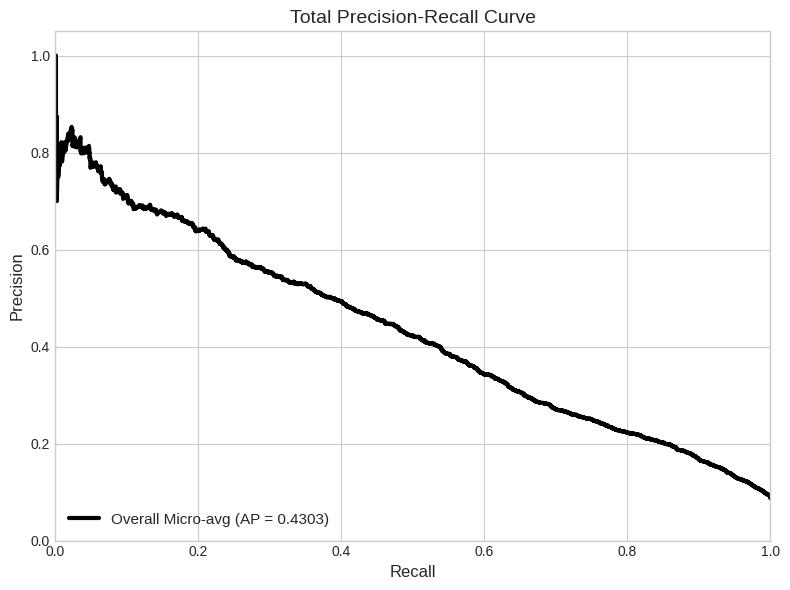

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

gt_np = gt.cpu().numpy()     # 形狀: (樣本數, 15)
pred_np = pred.cpu().numpy()   # 形狀: (樣本數, 15)

plt.figure(figsize=(8, 6))
plt.style.use('seaborn-v0_8-whitegrid')

print('\n' + '='*30)
print("=> PR 曲線指標計算")
print('-'*30)

ap_per_class = {}
for i, class_name in enumerate(CLASS_NAMES):
    if np.sum(gt_np[:, i]) > 0:
        ap_class = average_precision_score(gt_np[:, i], pred_np[:, i])
        ap_per_class[class_name] = ap_class
        print(f'疾病 {class_name:<20} 的 AP 分數 : {ap_class:.4f}')

# --- 計算與繪製整體曲線 ---
ap_macro = np.mean(list(ap_per_class.values()))

precision_micro, recall_micro, _ = precision_recall_curve(gt_np.ravel(), pred_np.ravel())
ap_micro = average_precision_score(gt_np.ravel(), pred_np.ravel())

print('-'*30)
print(f'Overall (Macro-avg) 的 AP 分數 : {ap_macro:.4f}')
print(f'Overall (Micro-avg) 的 AP 分數 : {ap_micro:.4f}')
print('='*30)

plt.plot(recall_micro, precision_micro, lw=3, color='black', label=f'Overall Micro-avg (AP = {ap_micro:.4f})')

record_path = f'{output_dir}/{MODEL_NAME}_global_pr_record.npz'
save_kwargs = {
    'recall': recall_micro,
    'precision': precision_micro,
    'ap_micro': np.array([ap_micro]),
    'ap_macro': np.array([ap_macro])
}
for c_name, score in ap_per_class.items():
    save_kwargs[f'ap_{c_name}'] = np.array([score])

np.savez(record_path, **save_kwargs)
print(f"=> 已儲存紀錄 {record_path}")

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Total Precision-Recall Curve', fontsize=14)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower left", fontsize=11)
plt.tight_layout()

plt.show()

#### ROC curve


=> ROC 曲線指標計算
------------------------------
疾病 Atelectasis          的 AUC 分數 : 0.7317
疾病 Cardiomegaly         的 AUC 分數 : 0.7037
疾病 Consolidation        的 AUC 分數 : 0.7180
疾病 Edema                的 AUC 分數 : 0.8149
疾病 Effusion             的 AUC 分數 : 0.8246
疾病 Emphysema            的 AUC 分數 : 0.7503
疾病 Fibrosis             的 AUC 分數 : 0.6965
疾病 Hernia               的 AUC 分數 : 0.3051
疾病 Infiltration         的 AUC 分數 : 0.6744
疾病 Mass                 的 AUC 分數 : 0.6921
疾病 No Finding           的 AUC 分數 : 0.7435
疾病 Nodule               的 AUC 分數 : 0.6556
疾病 Pleural_Thickening   的 AUC 分數 : 0.7823
疾病 Pneumonia            的 AUC 分數 : 0.5655
疾病 Pneumothorax         的 AUC 分數 : 0.7585
------------------------------
Overall (Macro-avg) 的 AUC 分數 : 0.6945
Overall (Micro-avg) 的 AUC 分數 : 0.8501
=> [已儲存整體與類別紀錄] model_10000/model_10000_global_roc_record.npz


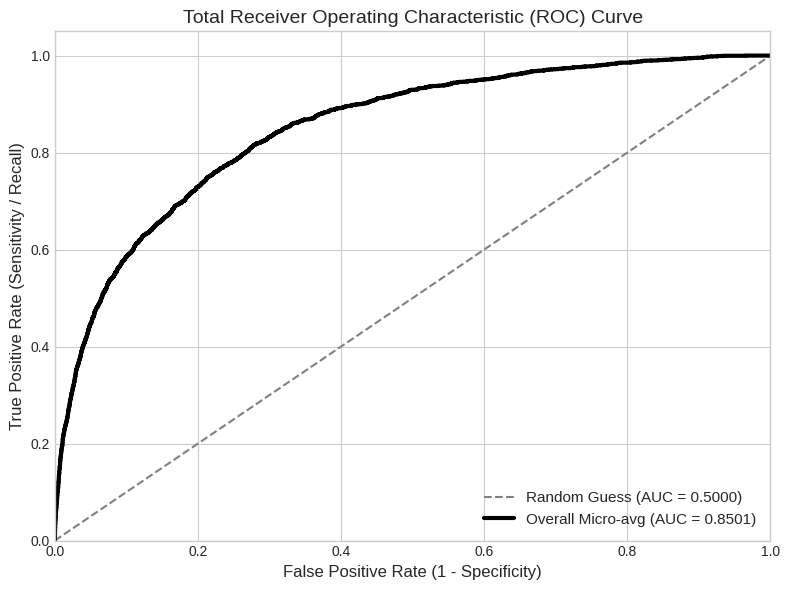

In [9]:
gt_np = gt.cpu().numpy()     # 形狀: (樣本數, 15)
pred_np = pred.cpu().numpy()   # 形狀: (樣本數, 15)

plt.figure(figsize=(8, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# 隨機猜測參考線
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.5000)')

print('\n' + '='*30)
print("=> ROC 曲線指標計算")
print('-'*30)

auc_per_class = {}
for i, class_name in enumerate(CLASS_NAMES):
    if (np.sum(gt_np[:, i] == 1) > 0) and (np.sum(gt_np[:, i] == 0) > 0):
        fpr_class, tpr_class, _ = roc_curve(gt_np[:, i], pred_np[:, i])
        roc_auc_class = auc(fpr_class, tpr_class)
        auc_per_class[class_name] = roc_auc_class
        print(f'疾病 {class_name:<20} 的 AUC 分數 : {roc_auc_class:.4f}')

# Macro AUC
auc_macro = np.mean(list(auc_per_class.values()))

# Micro AUC
fpr_global, tpr_global, _ = roc_curve(gt_np.ravel(), pred_np.ravel())
roc_auc_global = auc(fpr_global, tpr_global)

print('-'*30)
print(f'Overall (Macro-avg) 的 AUC 分數 : {auc_macro:.4f}')
print(f'Overall (Micro-avg) 的 AUC 分數 : {roc_auc_global:.4f}')
print('='*30)

plt.plot(fpr_global, tpr_global, lw=3, color='black', label=f'Overall Micro-avg (AUC = {roc_auc_global:.4f})')

# --- 儲存紀錄 ---
record_path = f'{output_dir}/{MODEL_NAME}_global_roc_record.npz'
save_kwargs = {
    'fpr': fpr_global,
    'tpr': tpr_global,
    'auc_micro': np.array([roc_auc_global]),
    'auc_macro': np.array([auc_macro])
}
for c_name, score in auc_per_class.items():
    save_kwargs[f'auc_{c_name}'] = np.array([score])

np.savez(record_path, **save_kwargs)
print(f"=> [已儲存整體與類別紀錄] {record_path}")
print('='*30)

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Total Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()

plt.show()

#### 熱區圖

In [10]:
import os
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

class ViTGradCAM:
    def __init__(self, model, target_module):
        self.model = model
        self.target_module = target_module
        self.activations = None
        self.gradients = None
        self.hook_forward = target_module.register_forward_hook(self.save_activation)
        self.hook_backward = target_module.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        # 安全取法：確保拿到的是 tensor 且脫離計算圖
        if isinstance(grad_output, tuple):
            self.gradients = grad_output[0].detach()
        else:
            self.gradients = grad_output.detach()

    def __call__(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        
        if input_tensor.dim() == 3:
            input_tensor = input_tensor.unsqueeze(0)
            
        output = self.model(input_tensor)
        
        if output.dim() == 1:
            output = output.unsqueeze(0)
        elif output.dim() == 3:
            output = output.mean(dim=1)

        if class_idx is None:
            class_idx = torch.argmax(output[0]).item()

        target = output[0, class_idx]
        target.backward(retain_graph=True)

        # ==================== ViT 專屬的特徵還原邏輯 ====================
        act = self.activations[0]  # [Token_Num, Embedding_Dim]
        grad = self.gradients[0]   # [Token_Num, Embedding_Dim]

        # 移除第 0 位的 [CLS] token，只保留純影像的 Patch 特徵
        act = act[1:, :]
        grad = grad[1:, :]

        # 計算權重 (對 Token 維度求平均)
        weights = grad.mean(dim=0, keepdim=True) # [1, Embedding_Dim]
        
        # 加權求和並過 ReLU
        cam = torch.relu(torch.sum(weights * act, dim=-1)) # [Token_Num]
        cam = cam.cpu().numpy()

        # 將 1D 的 196 個 Tokens 還原回 2D 的 14x14 特徵圖大小
        grid_size = int(np.sqrt(cam.shape[0])) 
        cam = cam.reshape(grid_size, grid_size)

        # 歸一化到 0~255
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = np.uint8(cam * 255)
        cam = Image.fromarray(cam).resize((224, 224), resample=Image.BILINEAR)
        return np.array(cam) / 255.0

def overlay_heatmap(image, cam, alpha=0.5, cmap='jet'):
    heatmap = plt.get_cmap(cmap)(cam)[:, :, :3]
    heatmap = np.uint8(heatmap * 255)
    image = image.resize((224, 224))
    image_np = np.array(image).astype(np.uint8)
    overlay = np.uint8(image_np * (1.0 - alpha) + heatmap * alpha)
    return Image.fromarray(overlay)

# ==================== 設定與載入資料集 ====================
heatmap_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

vis_dataset = CustomChestXrayDataSet(
    csv_path=CSV_PATH,
    data_dir=DATA_DIR,
    split='test',
    transform=heatmap_transform,
    sample_level=round(SAMPLE_SIZE*0.2)
)

# 自動解開 DataParallel 安全鎖
model_for_cam = model.module if isinstance(model, torch.nn.DataParallel) else model

# 修正 1：不要掛在最外層的 global norm。強烈建議精確掛在最後一個 block 的第一個 LayerNorm
if hasattr(model_for_cam, 'blocks') and len(model_for_cam.blocks) > 0:
    target_layer = model_for_cam.blocks[-1].norm1
elif hasattr(model_for_cam, 'layers') and len(model_for_cam.layers) > 0: # 部分車輪實作叫 layers
    target_layer = model_for_cam.layers[-1].norm1
else:
    # 備用保險方案
    target_layer = model_for_cam.norm

gradcam = ViTGradCAM(model_for_cam, target_layer)

output_dir = f'gradcam_{MODEL_NAME}_{SAMPLE_SIZE}'
os.makedirs(output_dir, exist_ok=True)

# ==================== 全量預測以找出 TP, FP, TN, FN ====================
print(f'=> 正在分析測試集預測結果 ({MODEL_NAME}) 以篩選 TP/FP/TN/FN...')
all_gts = []
all_preds = []

model.eval()
with torch.no_grad():
    for idx in range(len(vis_dataset)):
        input_tensor, label = vis_dataset[idx]
        
        if input_tensor.dim() == 3:
            input_tensor = input_tensor.unsqueeze(0)
            
        input_tensor = input_tensor.to(device)
        output = model(input_tensor)
            
        prob = torch.sigmoid(output).cpu().numpy()[0]
        
        all_gts.append(label.numpy().flatten())
        all_preds.append(prob.flatten())

all_gts = np.array(all_gts).astype(int)
all_preds = np.array(all_preds).astype(float)
all_pred_labels = (all_preds >= 0.5).astype(int)

print('=> 開始生成 ViT Grad-CAM 熱區圖')
conditions = ['TP', 'FP', 'TN', 'FN']

for c_idx, class_name in enumerate(CLASS_NAMES):
    if class_name not in ['Effusion', 'Nodule', 'No Finding']:
        continue
    print(f'  類別 [{class_name}]:')
    
    y_true = all_gts[:, c_idx]
    y_pred = all_pred_labels[:, c_idx]
    
    idx_groups = {
        'TP': np.where((y_true == 1) & (y_pred == 1))[0],
        'FP': np.where((y_true == 0) & (y_pred == 1))[0],
        'TN': np.where((y_true == 0) & (y_pred == 0))[0],
        'FN': np.where((y_true == 1) & (y_pred == 0))[0]
    }
    
    for cond in conditions:
        target_indices = idx_groups[cond]
        
        if len(target_indices) == 0:
            print(f'    - {cond}: 沒有符合的樣本，跳過。')
            continue
            
        selected_idx = target_indices[0]
        
        try:
            row = vis_dataset.df.iloc[selected_idx]
            raw_image = Image.open(os.path.join(DATA_DIR, row['Image Index'])).convert('RGB')
            input_tensor, _ = vis_dataset[selected_idx]
            
            if input_tensor.dim() == 3:
                input_tensor = input_tensor.unsqueeze(0)
            input_tensor = input_tensor.to(device)
            
            prob = all_preds[selected_idx, c_idx]
            
            # 計算 ViT 專用的 Grad-CAM
            cam = gradcam(input_tensor, class_idx=c_idx)
            overlay = overlay_heatmap(raw_image, cam, alpha=0.45)
            
            save_name = f'{output_dir}/{selected_idx}_{class_name}_{cond}_{prob:.3f}.png'
            overlay.save(save_name)
            print(f'    - {cond}: 已儲存 {save_name} (真實:{y_true[selected_idx]} | 預測:{y_pred[selected_idx]})')
        except Exception as img_err:
            print(f'    - {cond}: 繪圖失敗 ({img_err})')

print(f' => ViT Grad-CAM 圖片已全數處理完畢，儲存於 {output_dir}/')

=> 正在分析測試集預測結果 (model_10000) 以篩選 TP/FP/TN/FN...
=> 開始生成 ViT Grad-CAM 熱區圖
  類別 [Effusion]:
    - TP: 已儲存 gradcam_model_10000_10000/19_Effusion_TP_0.500.png (真實:1 | 預測:1)
    - FP: 已儲存 gradcam_model_10000_10000/28_Effusion_FP_0.611.png (真實:0 | 預測:1)
    - TN: 已儲存 gradcam_model_10000_10000/0_Effusion_TN_0.466.png (真實:0 | 預測:0)
    - FN: 已儲存 gradcam_model_10000_10000/4_Effusion_FN_0.490.png (真實:1 | 預測:0)
  類別 [No Finding]:
    - TP: 已儲存 gradcam_model_10000_10000/37_No Finding_TP_0.507.png (真實:1 | 預測:1)
    - FP: 已儲存 gradcam_model_10000_10000/38_No Finding_FP_0.554.png (真實:0 | 預測:1)
    - TN: 已儲存 gradcam_model_10000_10000/3_No Finding_TN_0.234.png (真實:0 | 預測:0)
    - FN: 已儲存 gradcam_model_10000_10000/0_No Finding_FN_0.248.png (真實:1 | 預測:0)
  類別 [Nodule]:
    - TP: 已儲存 gradcam_model_10000_10000/125_Nodule_TP_0.500.png (真實:1 | 預測:1)
    - FP: 已儲存 gradcam_model_10000_10000/85_Nodule_FP_0.517.png (真實:0 | 預測:1)
    - TN: 已儲存 gradcam_model_10000_10000/0_Nodule_TN_0.254.png (真實:0 | 預測:0)
    - FN: